In [1]:
### this combines what had been in 2 notebooks
import sys
sys.path.append('../../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

large_data_dir = gf_utils.large_data_dir


# Compute p swap

mkdir: cannot create directory ‘output/likelihood_tables_GBM’: File exists


819118 UMIs found
Collapsing UMIs across probes, 819118 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 792315 UMIs remaining (96.73%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 755337 UMIs remaining (92.21%)
number of probes to use: 19


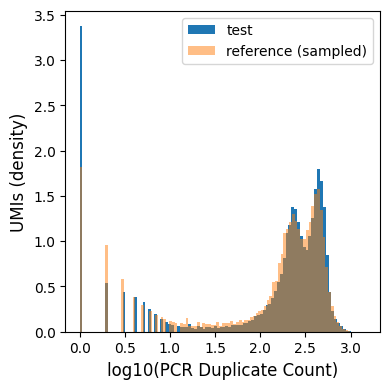

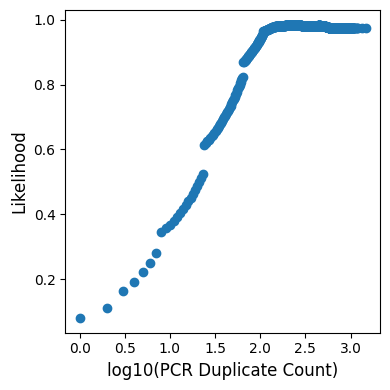

In [ ]:
lib = 'GBM'
    
os.system('mkdir output/likelihood_tables_' + lib)

BC = 'BC002'

### first get probe_reads to use for the patient
adata_path = large_data_dir + 'GBM_' + BC + '_genotyped.h5ad' ### this is just for cell names; it would not usually use the genotyped h5ad because it wouldn't be generated yet, but cell names are the same so we use it here to not have to upload a redundant h5ad just for this step
gf_dir = large_data_dir + 'gf_decrosslink_4plex/BC' + str(int(BC.replace('BC',''))) + '_giftwrap/'
    
manifest = gf_utils.get_manifest(gf_dir)
min_percent_supporting = 0.9
collapse_across_probes = True

probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold = 0, adata_path = adata_path, min_percent_supporting=min_percent_supporting, collapse_across_probes=collapse_across_probes)
probe_reads_patient = probe_reads.copy()

patient_min_threshold = 8 ## min_threshold is an inclusive read threshold above obvious background, helpful for finding knee point

### then use cell line as reference to get probability of a PCR swap based on read count
### adjust inputs below as needed
gf_dir = large_data_dir + 'gf_likelihood_model_cell_line_ref/'
adata_path = large_data_dir + 'likelihood_model_cell_line_ref.h5ad'

expected_genotypes_file = 'data/cl_reference_predicted_genotypes.csv'

probe_reads_cl = pd.read_csv('data/cl_reference_probe_reads.tsv.gz', sep='\t')

cl_min_threshold = 10 ## min_threshold is an inclusive threshold above obvious background

### now sample the cell line distribution and get probability of pcr swaps for the patient
### plots are output for sanity checks
prob_real = gf_utils.sample_and_get_swap_probabilities(probe_reads_patient, probe_reads_cl, patient_min_threshold, cl_min_threshold, expected_genotypes_file)

prob_real.to_csv('output/likelihood_tables_' + lib + '/patient_' + BC + '_swap_probabilities.csv', index=True)


# Save frequencies of every observed gapfill with edit distance probability

In [3]:
def get_wt_likelihood(gapfill,error_rate_dicts,wt_gapfill):
    likelihoods = gf_utils.get_likelihoods_of_true_allele(gapfill, error_rate_dicts)
    if wt_gapfill in likelihoods:
        return likelihoods[wt_gapfill]
    else:
        return None

### load error rates for edit distance calculation
error_rate_dir = 'data/error_rate_dicts'
error_rate_dicts = gf_utils.get_error_rate_dicts(error_rate_dir)


In [4]:
### save frequencies of every observed gapfill with likelihoods from edit distance model #####
os.system('mkdir output/unexpected_gapfills_' + lib)

exclude_keyword = '0bp'
if 'gapfill_from_transcriptome' not in probe_reads.columns:
    probe_reads = probe_reads.merge(manifest[['gapfill_from_transcriptome','gapfill_start','gap_probe_sequence','name','lhs_probe','rhs_probe']], left_on='probe_idx',right_index=True,how='left')
probe_reads['gapfill'] = probe_reads['gapfill'].fillna('')
probe_reads['gapfill_from_transcriptome'] = probe_reads['gapfill_from_transcriptome'].fillna('')
if probe_reads['name'].isna().any():
    raise ValueError('Probes with no name found in probe reads for ' + BC)
probe_reads = probe_reads.loc[probe_reads['name'].str.contains(exclude_keyword) == False]

counts_in_library = len(probe_reads)
gapfill_frequencies = probe_reads.groupby('probe_idx')['gapfill'].value_counts(normalize=True).rename('frequency').reset_index()
gapfill_counts = probe_reads.groupby('probe_idx')['gapfill'].value_counts().rename('count_of_this_gapfill').reset_index()
probe_counts = probe_reads.groupby('probe_idx').size().rename('count_of_this_probe').reset_index()

to_resolve = probe_reads[['probe_idx','name','gapfill','gapfill_from_transcriptome','gapfill_start','gap_probe_sequence','lhs_probe','rhs_probe']].drop_duplicates()
to_resolve['likelihood'] = to_resolve.apply(
    lambda row: get_wt_likelihood(row['gapfill'], error_rate_dicts, row['gapfill_from_transcriptome']), axis=1
)
to_resolve = to_resolve.merge(gapfill_frequencies, on = ['probe_idx','gapfill'], how='left')
to_resolve = to_resolve.merge(gapfill_counts, on = ['probe_idx','gapfill'], how='left')
to_resolve = to_resolve.merge(probe_counts, on = ['probe_idx'], how='left')

to_add = manifest.loc[~(manifest.index.isin(to_resolve['probe_idx'])) & (manifest['name'].str.contains(exclude_keyword) == False)].reset_index().rename(columns={'index': 'probe_idx'})
to_resolve = pd.concat([to_resolve, to_add[['probe_idx','name','gapfill_from_transcriptome','gapfill_start','gap_probe_sequence','lhs_probe','rhs_probe']]]).reset_index(drop=True)
to_resolve[['count_of_this_gapfill','count_of_this_probe']] = to_resolve[['count_of_this_gapfill','count_of_this_probe']].fillna(0)
to_resolve.to_csv('output/unexpected_gapfills_' + lib + '/unresolved_gapfills_' + BC + '.csv', index=False)

mkdir: cannot create directory ‘output/unexpected_gapfills_GBM’: File exists
